In [1]:
import h5py
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from PIL import Image 
import polars as pl 
from joblib import Parallel, delayed
from io import BytesIO
from sklearn.preprocessing import TargetEncoder, OneHotEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_squared_error
import xgboost as xgb 
from imblearn.over_sampling import SMOTE

FILE_PATH = "./isic-2024-challenge/train-metadata.csv"
RESPONSE = "target"
FEATURES_TO_DROP = [
  "lesion_id", "iddx_full", "iddx_1", "iddx_2", "iddx_3", "iddx_4", "iddx_5",
  "mel_mitotic_index", "mel_thick_mm", "tbp_lv_dnn_lesion_confidence"
]

In [2]:
# Load training dataset
df = pd.read_csv(FILE_PATH, low_memory = False)

In [3]:
# Nan percentage of features only provided in training datset
df[FEATURES_TO_DROP].isna().sum(axis = 0) / df.shape[0]

lesion_id                       0.945001
iddx_full                       0.000000
iddx_1                          0.000000
iddx_2                          0.997337
iddx_3                          0.997345
iddx_4                          0.998626
iddx_5                          0.999998
mel_mitotic_index               0.999868
mel_thick_mm                    0.999843
tbp_lv_dnn_lesion_confidence    0.000000
dtype: float64

In [4]:
# EDA about `iddx` related variables
print("-" * 10, "Whole dataset response", "-" * 10)
print(f"Number of *Malignant* cases: {df[df[RESPONSE] == 1].shape[0]}")
print(f"Number of *Benign* cases: {df[df[RESPONSE] == 0].shape[0]}")
print(f"{(df.groupby('patient_id')[['target']].nunique() != 1).sum().item()} out of {df[df['target'] == 1]['patient_id'].nunique()} patients with a malignant target have records containing both benign and malignant data.")
print("-" * 10, "About `iddx_1` (all non-nan)", "-" * 10)
print(f"Number of *Indeterminate* cases: {df[df["iddx_1"] == "Indeterminate"].shape[0]}")
print(f"Number of *Benign* cases: {df[df["iddx_1"] == "Benign"].shape[0]}")
print(f"Number of *Malignant* cases: {df[df["iddx_1"] == "Malignant"].shape[0]}")
print("-" * 10, "About `iddx_2", "-" * 10)
print(f"Number of non-nan cases: {df[~df["iddx_2"].isna()].shape[0]}")
print(f"Number of non-nan and *Malignant* cases: {df[(~df["iddx_2"].isna()) & (df[RESPONSE] == 1)].shape[0]}")
print(f"Number of non-nan and *Benign* cases: {df[(~df["iddx_2"].isna()) & (df[RESPONSE] == 0)].shape[0]}")
print(f"Number of `iddx_1` Indeterminate and `iddx_2` non-nan cases: {df[(~df["iddx_2"].isna()) & (df["iddx_1"] == "Indeterminate")].shape[0]}")
print(f"{df[(df[RESPONSE] == 1) & (df["iddx_1"] == "Malignant") & (~df["iddx_2"].isna())].shape[0]} *Malignant* cases have been diagnosed *Malignant* in `iddx_1` and have non-nan `iddx_2`")
print("-" * 10, "**Key Inspection**", "-" * 10)
print(f"All *Malignant* cases have non-nan `iddx_1` and `iddx_2`")
print(f"All `iddx_1` *Indeterminate* cases have non-nan `iddx_2`")
print(f"All *Malignant* cases have been diagnosed *Malignant* in `iddx_1` and have non-nan `iddx_2`")

---------- Whole dataset response ----------
Number of *Malignant* cases: 393
Number of *Benign* cases: 400666
258 out of 259 patients with a malignant target have records containing both benign and malignant data.
---------- About `iddx_1` (all non-nan) ----------
Number of *Indeterminate* cases: 114
Number of *Benign* cases: 400552
Number of *Malignant* cases: 393
---------- About `iddx_2 ----------
Number of non-nan cases: 1068
Number of non-nan and *Malignant* cases: 393
Number of non-nan and *Benign* cases: 675
Number of `iddx_1` Indeterminate and `iddx_2` non-nan cases: 114
393 *Malignant* cases have been diagnosed *Malignant* in `iddx_1` and have non-nan `iddx_2`
---------- **Key Inspection** ----------
All *Malignant* cases have non-nan `iddx_1` and `iddx_2`
All `iddx_1` *Indeterminate* cases have non-nan `iddx_2`
All *Malignant* cases have been diagnosed *Malignant* in `iddx_1` and have non-nan `iddx_2`


In [5]:
# Store response
response = df[[RESPONSE]]
# Drop features only provided in training dataset
df.drop(FEATURES_TO_DROP, axis = 1, inplace = True)

In [6]:
# Remaining features summary
df.drop("target", axis = 1).info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 401059 entries, 0 to 401058
Data columns (total 44 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   isic_id                      401059 non-null  object 
 1   patient_id                   401059 non-null  object 
 2   age_approx                   398261 non-null  float64
 3   sex                          389542 non-null  object 
 4   anatom_site_general          395303 non-null  object 
 5   clin_size_long_diam_mm       401059 non-null  float64
 6   image_type                   401059 non-null  object 
 7   tbp_tile_type                401059 non-null  object 
 8   tbp_lv_A                     401059 non-null  float64
 9   tbp_lv_Aext                  401059 non-null  float64
 10  tbp_lv_B                     401059 non-null  float64
 11  tbp_lv_Bext                  401059 non-null  float64
 12  tbp_lv_C                     401059 non-null  float64
 13 

In [7]:
# Glance of remaining features
df.drop("target", axis = 1).head(5).T

,0,1,2,3,4
isic_id,ISIC_0015670,ISIC_0015845,ISIC_0015864,ISIC_0015902,ISIC_0024200
patient_id,IP_1235828,IP_8170065,IP_6724798,IP_4111386,IP_8313778
age_approx,60.0,60.0,60.0,65.0,55.0
sex,male,male,male,male,male
anatom_site_general,lower extremity,head/neck,posterior torso,anterior torso,anterior torso
clin_size_long_diam_mm,3.04,1.1,3.4,3.22,2.73
image_type,TBP tile: close-up,TBP tile: close-up,TBP tile: close-up,TBP tile: close-up,TBP tile: close-up
tbp_tile_type,3D: white,3D: white,3D: XP,3D: XP,3D: white
tbp_lv_A,20.244422,31.71257,22.57583,14.242329,24.72552
tbp_lv_Aext,16.261975,25.36474,17.12817,12.164757,20.05747


In [8]:
# Summary of categorical features
CATEGORICAL_FEATURES = ["isic_id", "patient_id", "sex", "anatom_site_general", "image_type", "tbp_tile_type", "tbp_lv_location", "tbp_lv_location_simple", "attribution", "copyright_license"]
df[CATEGORICAL_FEATURES].nunique()

isic_id                   401059
patient_id                  1042
sex                            2
anatom_site_general            5
image_type                     1
tbp_tile_type                  2
tbp_lv_location               21
tbp_lv_location_simple         8
attribution                    7
copyright_license              3
dtype: int64

In [9]:
# Further drop features
FEATURES_TO_DROP_FURTHER = ["sex", "image_type", "attribution", "copyright_license", "tbp_tile_type"]
df.drop(FEATURES_TO_DROP_FURTHER, axis = 1, inplace = True)

In [10]:
# Nan percentage of remaining features
nan_percentage = (df.isna().sum(axis = 0) / df.shape[0])
nan_percentage[nan_percentage > 0]

age_approx             0.006977
anatom_site_general    0.014352
dtype: float64

In [11]:
# Impute missing values in `age_approx` and `anatom_site_general`
FEATURE_TO_IMPUTE = ["age_approx", "anatom_site_general"]
imputer = SimpleImputer(strategy = "most_frequent")
df[FEATURE_TO_IMPUTE] = imputer.fit_transform(df[FEATURE_TO_IMPUTE])

In [12]:
# Taget Encoding result of `anatom_site_general`
df.groupby("anatom_site_general")["target"].agg(
  ["count", "mean"]
)

,count,mean
anatom_site_general,,
anterior torso,87770,0.000934
head/neck,12046,0.006475
lower extremity,103028,0.000709
posterior torso,127658,0.000807
upper extremity,70557,0.000808


In [13]:
# Taget Encoding result of `tbp_lv_location`
df.groupby("tbp_lv_location")["target"].agg(
  ["count", "mean"]
)

,count,mean
tbp_lv_location,,
Head & Neck,12046,0.006475
Left Arm,1593,0.001255
Left Arm - Lower,11939,0.001005
Left Arm - Upper,22816,0.000877
Left Leg,1974,0.003040
Left Leg - Lower,27428,0.000875
Left Leg - Upper,23673,0.000591
Right Arm,601,0.000000
Right Arm - Lower,10636,0.000470


In [14]:
# Taget Encoding result of `tbp_lv_location_simple`
df.groupby("tbp_lv_location_simple")["target"].agg(
  ["count", "mean"]
)

,count,mean
tbp_lv_location_simple,,
Head & Neck,12046,0.006475
Left Arm,36348,0.000935
Left Leg,53075,0.000829
Right Arm,34209,0.000672
Right Leg,49953,0.000581
Torso Back,121902,0.000845
Torso Front,87770,0.000934
Unknown,5756,0.000000


In [15]:
# Encoding categorical features 
TARGETENCODING_FEATURES = ["anatom_site_general", "tbp_lv_location", "tbp_lv_location_simple"]
targetencoder = TargetEncoder(target_type = "binary")
df[TARGETENCODING_FEATURES] = targetencoder.fit_transform(df[TARGETENCODING_FEATURES], df[RESPONSE])
#ONEHOTENCODING_FEATURES = ["tbp_tile_type"]
#onehotencoder = OneHotEncoder(sparse_output = False)
#onehot_encoded_array = onehotencoder.fit_transform(df[ONEHOTENCODING_FEATURES])
#df[ONEHOTENCODING_FEATURES] = onehot_encoded_array.argmax(axis = 1).reshape(-1, 1).astype(np.float64)

In [16]:
# Scale features
FEATURES_TO_SCALE = df.columns.drop(["isic_id", "patient_id"])
scaler = MinMaxScaler(feature_range = (0, 1))
df[FEATURES_TO_SCALE] = scaler.fit_transform(df[FEATURES_TO_SCALE])

In [17]:
# Sampler to generate synthetic positive case data
sampler = SMOTE(sampling_strategy = 0.3, random_state = 42)
FEATURES = FEATURES_TO_SCALE.drop(RESPONSE)
X, y = sampler.fit_resample(df[FEATURES], df[RESPONSE])

In [18]:
df.head(5).T

,0,1,2,3,4
isic_id,ISIC_0015670,ISIC_0015845,ISIC_0015864,ISIC_0015902,ISIC_0024200
target,0.0,0.0,0.0,0.0,0.0
patient_id,IP_1235828,IP_8170065,IP_6724798,IP_4111386,IP_8313778
age_approx,0.6875,0.6875,0.6875,0.75,0.625
anatom_site_general,0.0,0.782216,0.021194,0.04554,0.047428
clin_size_long_diam_mm,0.074453,0.00365,0.087591,0.081022,0.063139
tbp_lv_A,0.44856,0.67486,0.494565,0.330121,0.536985
tbp_lv_Aext,0.5497,0.747149,0.568489,0.460827,0.632028
tbp_lv_B,0.502444,0.491697,0.703178,0.402979,0.49413
tbp_lv_Bext,0.376069,0.39126,0.619598,0.303669,0.420931


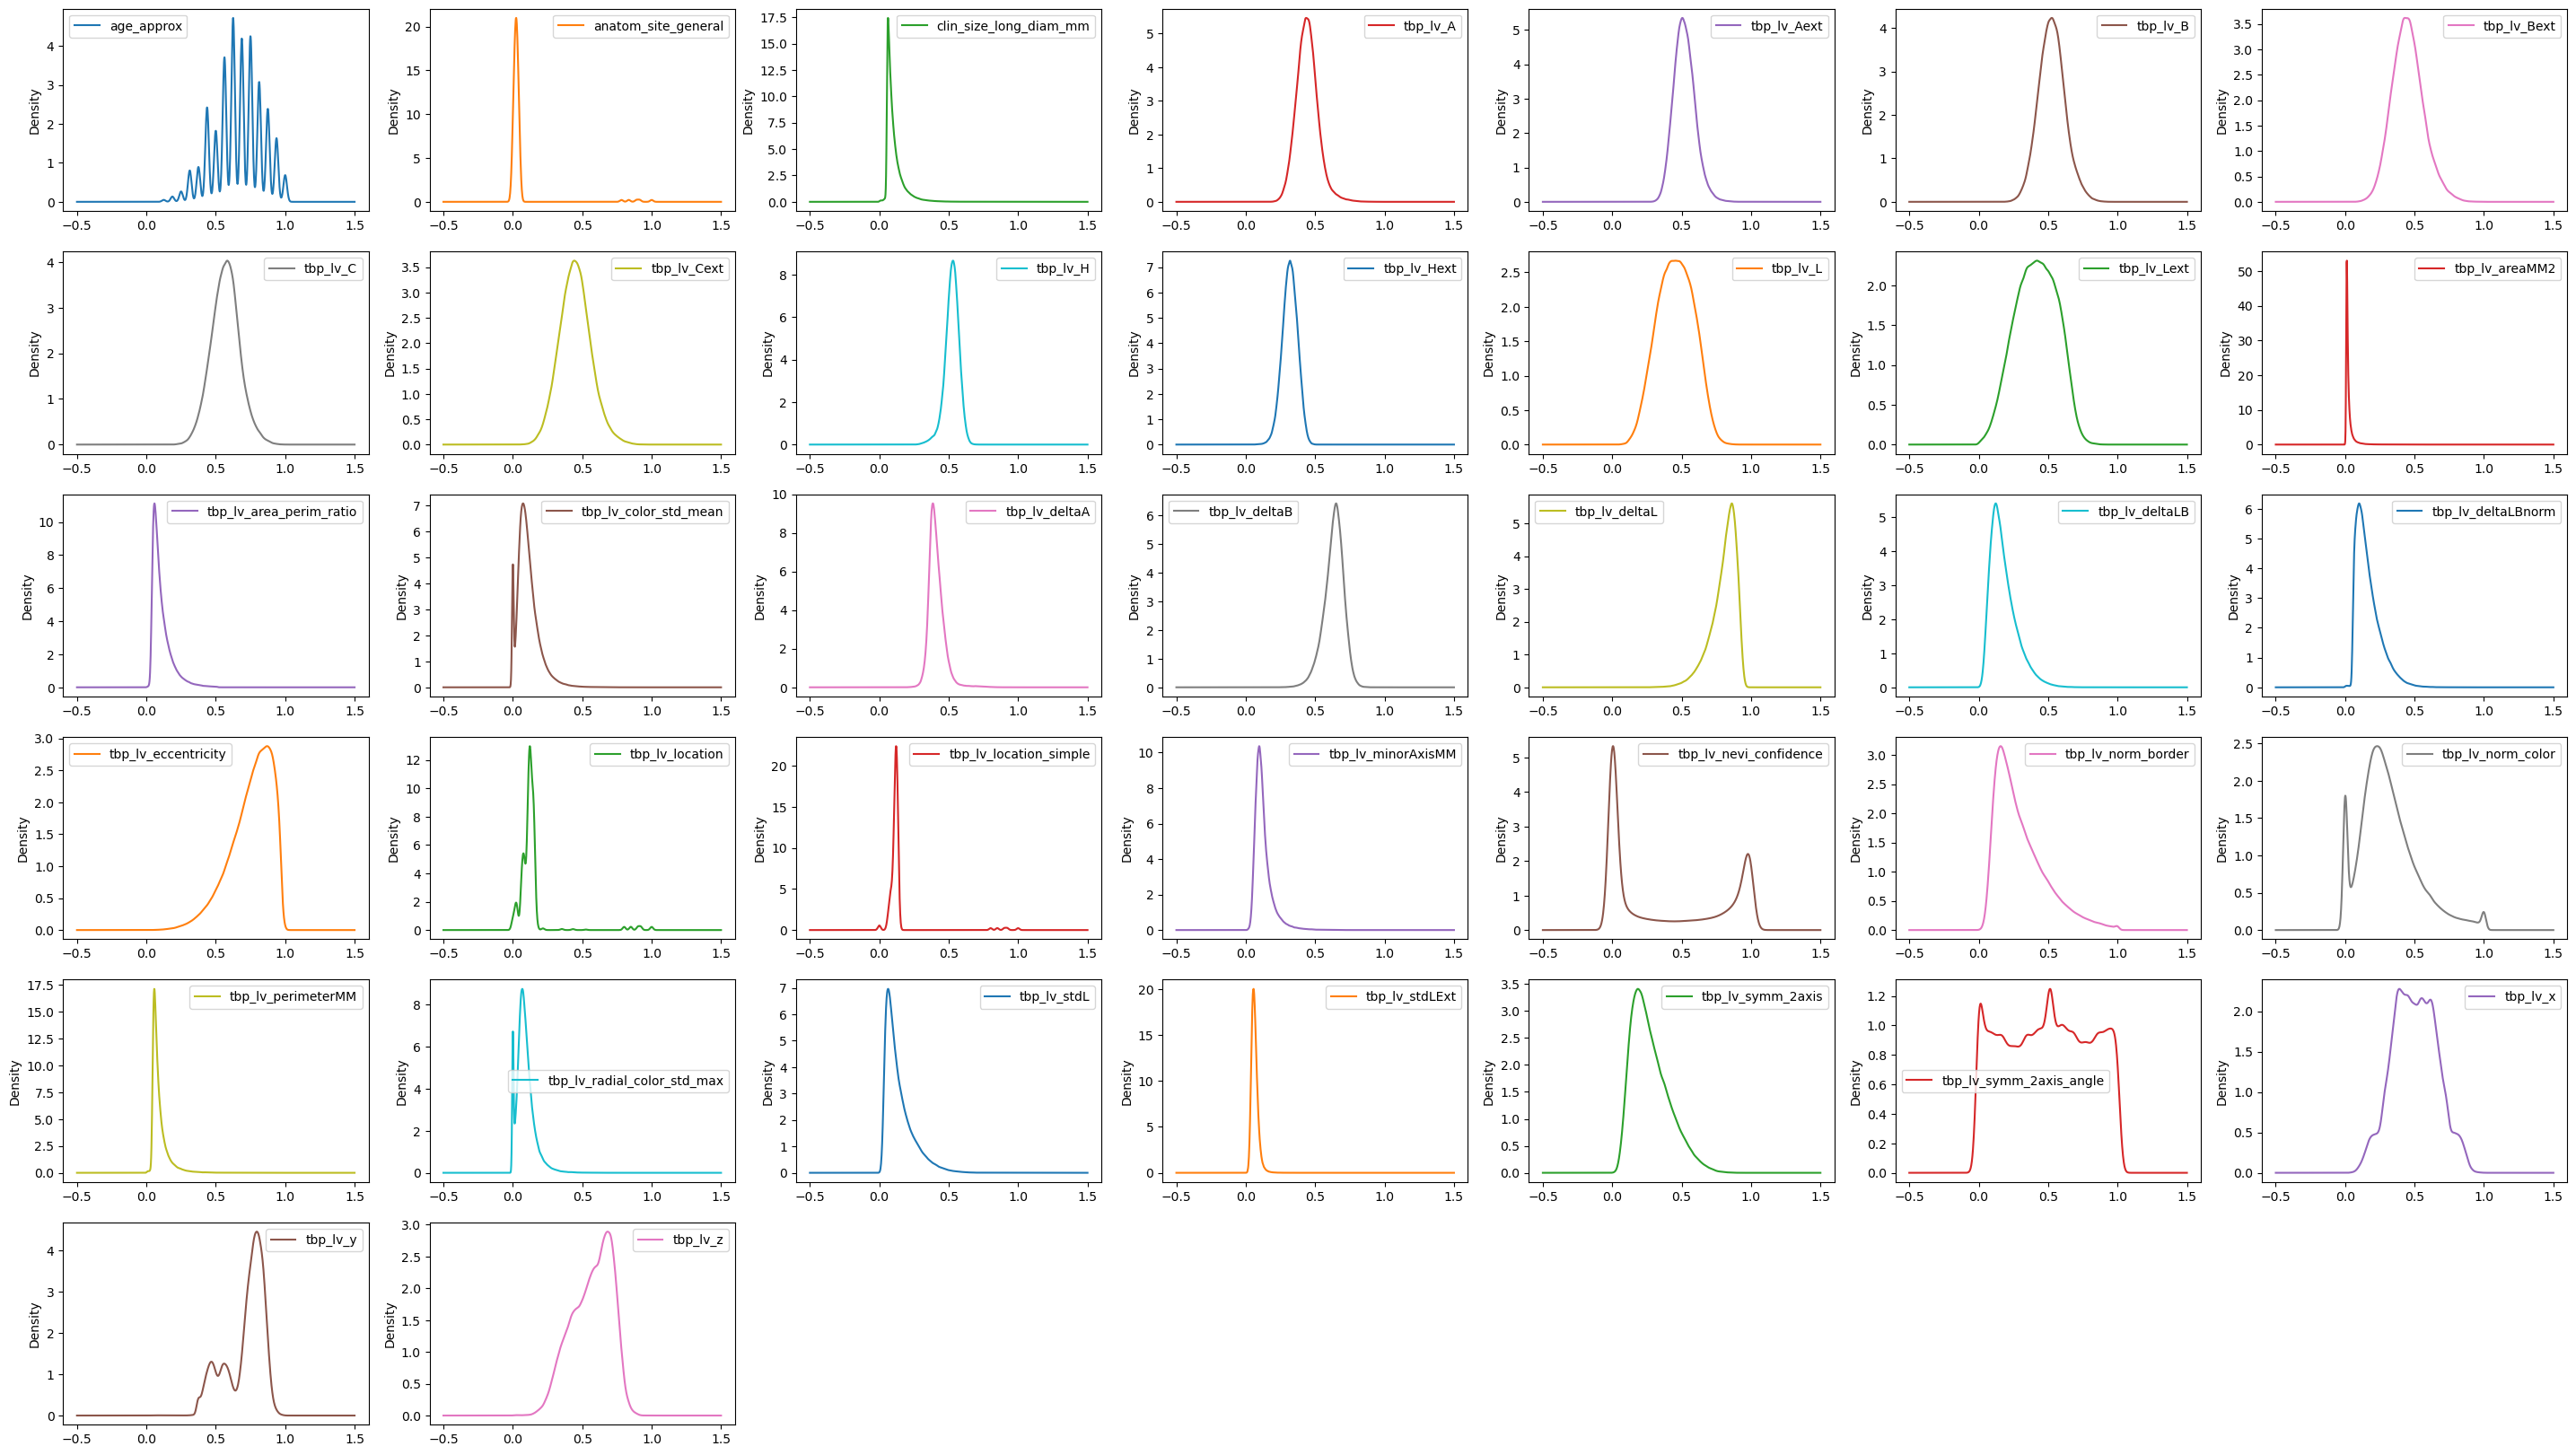

In [19]:
df[FEATURES].plot(kind='density', subplots=True, layout=(7, 7), figsize=(36, 24), sharex=False)
plt.show()

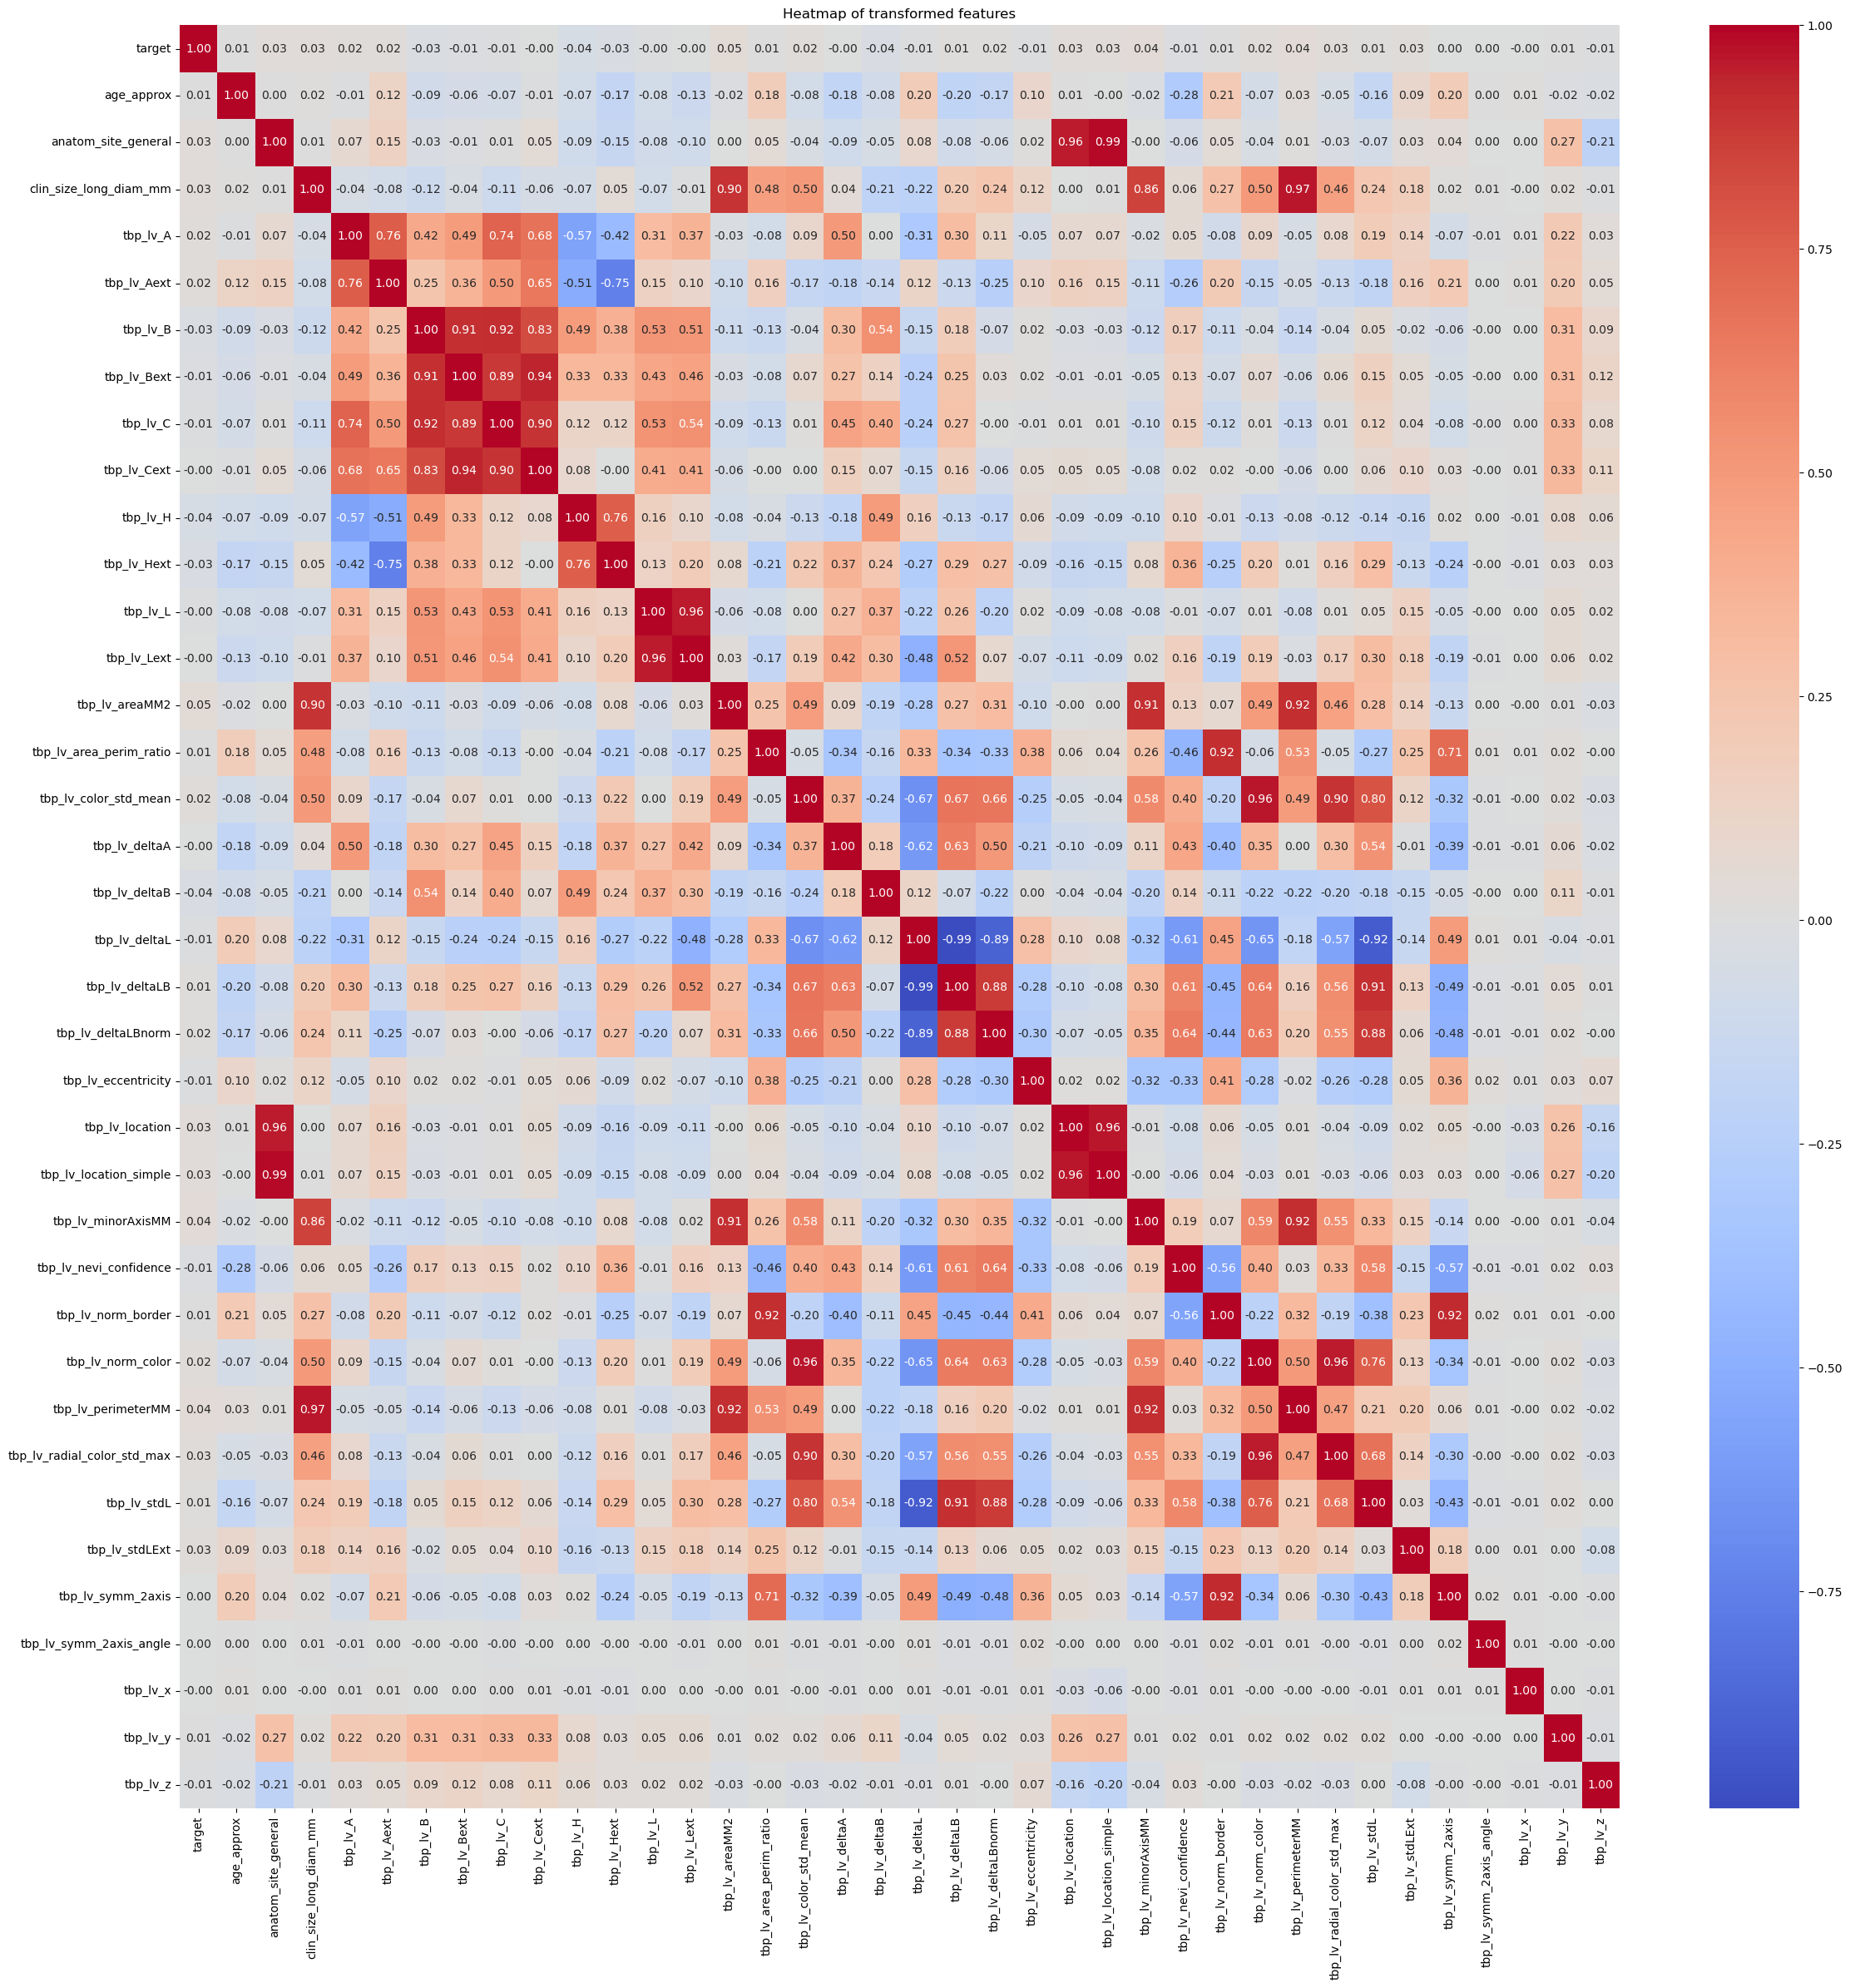

In [20]:
plt.figure(figsize = (24, 24))
corr_matrix = df[FEATURES_TO_SCALE].corr()
sns.heatmap(corr_matrix, annot = True, fmt = ".2f", annot_kws = {"size": 10}, cmap = "coolwarm")
plt.title("Heatmap of transformed features")
plt.tight_layout()
plt.show()

In [21]:
rf = RandomForestClassifier(100, min_samples_leaf = 10)
rf.fit(df[FEATURES], df[RESPONSE])

RandomForestClassifier(min_samples_leaf=10)

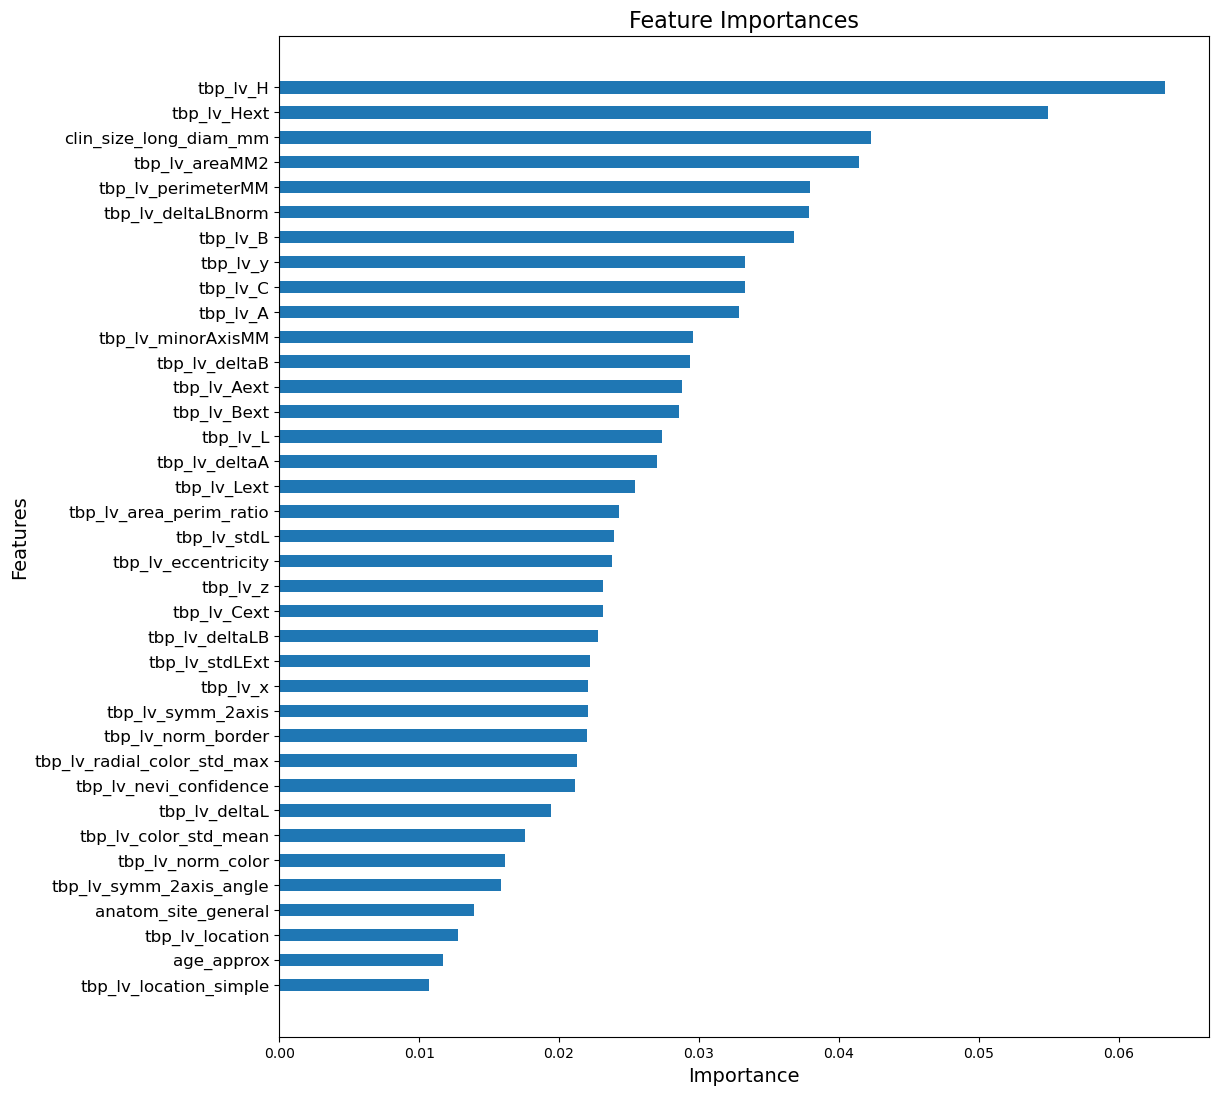

In [22]:
importance = rf.feature_importances_
df_imp = pd.DataFrame({'feature': FEATURES, 'importance': importance}).sort_values('importance', ascending=True)
fig, ax = plt.subplots(figsize=(12, 13))
ax.barh(df_imp['feature'], df_imp['importance'], height=0.5)
plt.xlabel('Importance', fontsize=14)
plt.ylabel('Features', fontsize=14)
plt.title('Feature Importances', fontsize=16)
ax.tick_params(axis='y', labelsize=12)
plt.show()

In [23]:
xgb_classifier = xgb.XGBClassifier()
xgb_classifier.fit(df[FEATURES], df[RESPONSE])

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

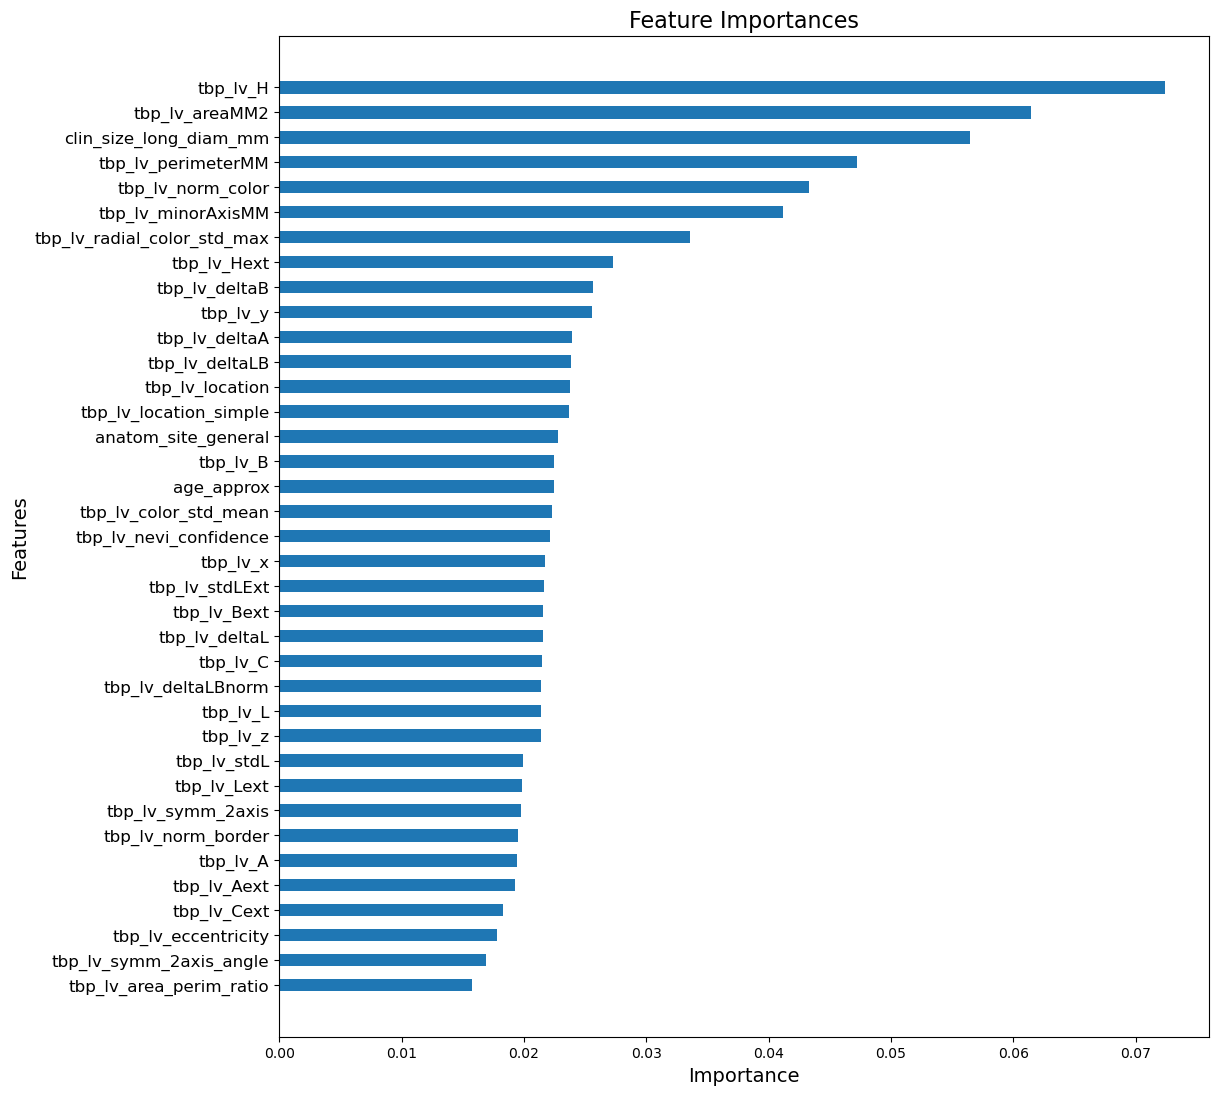

In [24]:
importance = xgb_classifier.feature_importances_
df_imp = pd.DataFrame({'feature': FEATURES, 'importance': importance}).sort_values('importance', ascending=True)
fig, ax = plt.subplots(figsize=(12, 13))
ax.barh(df_imp['feature'], df_imp['importance'], height=0.5)
plt.xlabel('Importance', fontsize=14)
plt.ylabel('Features', fontsize=14)
plt.title('Feature Importances', fontsize=16)
ax.tick_params(axis='y', labelsize=12)
plt.show()